# Object recognition & Neural Network security

## Part A - Application area review
### Object recognition

**Object recognition** is an important part of computer vision, that identifies and localise specific objects in digital images or video frames. This field includes several tasks, such as:
- *image classification*, which assigns a label to an image; 
- *object localisation*, which identifies the location of an object;
- *object detection*, which involves locating and classifying multiple objects. [1][2] 

The evolution of this technology is broadly split into two distinct eras: the period of traditional methods utilising manual extracted features, prior to 2012, and the subsequent deep learning era, dominated by Convolutional Neural Networks (CNNs). [1]

Object detection methodologies used to rely heavily on manually extracted features in order to get important information from pixels. Principal techniques included the **Scale-Invariant Feature Transform (SIFT)**, which focused on detecting key points and generating local descriptors important to scale, and the **Histogram of Oriented Gradients (HOG)**, which calculated gradient histograms. [1] These features were often paired with classifiers such as *Support Vector Machines (SVMs)* or employed in *Deformable Part Models (DPM)* to handle pose variations. [2] The performance of these systems was strictly constrained by the quality of the manual feature design, which often failed to capture high-level semantic representations. [2]

The field transformed significantly in 2012 with the success of *AlexNet* in the **ImageNet Large Scale Visual Recognition Challenge (ILSVRC)**, which demonstrated the superior capability of deep **Convolutional Neural Networks (CNNs)** over traditional methods. [3][4] Unlike their predecessors, CNNs automatically learn hierarchical feature representations directly from raw data, eliminating the need for manual feature engineering. Innovations such as the *Rectified Linear Unit (ReLU)* activation function and Dropout regularisation were critical in training these deep networks effectively by addressing issues like gradient disappearance and overfitting. [1] Following AlexNet, architectures such as *VGGNet* demonstrated that increasing network depth using very small (3x3) convolution filters could significantly improve accuracy. [4][5] Furthermore, architectures like *ResNet* introduced residual connections to enable the training of extremely deep networks, while *MobileNetV2* utilised inverted residuals and linear bottlenecks to optimise performance for resource-constrained mobile environments.[6]

Post-2012, object detection methodologies generally split into two-stage and one-stage detectors. Two-stage detectors, exemplified by the **Region-based Convolutional Neural Networks (R-CNN)** family, prioritise accuracy. The original R-CNN combined selective search for region proposals with CNN-based feature extraction but was computationally expensive. [1][2] Fast R-CNN improved efficiency by employing Region of Interest (RoI) pooling to share computation across proposals. [3] Faster R-CNN further advanced this by introducing a *Region Proposal Network (RPN)* to generate proposals end-to-end, sharing convolutional features with the detection network. [10] Mask R-CNN extended this architecture to perform instance segmentation by adding a branch for predicting object masks. [2][6]

On the other hand, one-stage detectors prioritise prediction speed, making them suitable for real-life applications. The **YOLO (You Only Look Once)** architecture redefined this approach by framing detection as a single regression problem, predicting bounding boxes and class probabilities directly from full images in a single forward pass. [3] While early versions of YOLO struggled with small objects, later developments (YOLOv2 to YOLOv8) introduced improvements such as anchor boxes, multi-scale training, and batch normalization to enhance accuracy and reliability. [1]

Recent advancements have introduced Transformer-based architectures, shifting the field toward end-to-end detection without manual extracted components like Non-Maximum Suppression (NMS). The *Detection Transformer (DETR)* utilises a transformer encoder-decoder structure and self-attention mechanisms to model global dependencies and predict object sets directly. [1]Variants like *Deformable DETR* and *Efficient DETR* have since emerged to address the slow convergence and high computational costs associated with the original DETR model. Additionally, *Vision Transformers (ViT)* apply transformer architectures directly to image patches for classification, further challenging the dominance of CNNs. [3]

The development of these algorithms is directly linked to large-scale annotated datasets. Pascal VOC served as an early benchmark, while *ImageNet* (15 million images) catalysed the deep learning revolution. [1] The MS COCO dataset presented more complex challenges with diverse object scales and occlusions, becoming a standard for modern detection evaluation. [3] Evaluation metrics have also standardized, with Intersection over Union measuring localization accuracy and Mean Average Precision serving as the primary metric for overall detection performance across classes. For real-time applications, Frames Per Second (FPS) is critical, often necessitating a trade-off between speed and accuracy. [2] Future directions in the field include 3D object detection using LiDAR point clouds, multi-modal detection integrating video and audio, and weakly supervised learning to reduce reliance on massive annotated datasets. [4][8]

## Part B – Compare and evaluate AI techniques
Three AI techniques most common used in object recognition:
- Convolutional Neural Networks (CNNs)
- Traditional Neural Networks with Manual Extracted Features
- Clustering (Unsupervised Learning)

#### 1. Convolutional Neural Networks (CNNs)
**Description:** CNNs are deep learning models designed to process matrix data such as images. Unlike traditional networks, they employ convolutional layers to automatically extract image features from low level edges to high level patterns directly from raw pixel data.[3] Modern architectures like MobileNetV2 use advanced structures like "inverted residuals" to perform these operations efficiently on mobile devices.[6]
- **Strengths:** CNNs currently offer state-of-the-art accuracy on large scale models like ImageNet and MS COCO. They are highly robust to translation, scaling, and rotation variations because they learn invariant features automatically. [3][9]
- **Weaknesses:** They require a high amount of training data for the model to have a good accuracy. They are computationally expensive, often requiring GPUs for training. Furthermore, they function as "black boxes", making their decision-making process difficult to interpret.[4][7]
- **Input/Output:** Input is image pixel arrays; Output is a set of class labels and their confidence.
- **Best Suited For:** Complex visual patterns that are difficult to describe with hand-crafted rules. [1]

#### 2. Traditional Neural Networks with Manual Extracted Features
**Description:** This approach is a hybrid of classical computer vision and basic machine learning. It is a two-step process: first, a feature extraction algorithm is applied to the image to generate a feature vector describing shapes, gradients, etc. Second, this vector is fed into a standard fully connected neural network to perform the classification. [1][3]
- **Strengths:** This method is more interpretable than deep CNNs because the features are mathematically defined and understood. It requires significantly less computational power for the model training and can perform better than CNNs on very small datasets where deep models would overfit.[2]
- **Weaknesses:** The system's performance is constrained by the quality of the extracted features. These methods generally have lower accuracy on more complex datasets compared to simpler ones. [2][3]
- **Input/Output:** Input is a feature vector; Output is a class label (classification).
- **Best Suited For:** Limited computational power. This method is used for classification.

#### 3. Clustering (Unsupervised Learning)
**Description:** Clustering algorithms, such as K-means, group data points based on similarity without using labeled training data. In object recognition, clustering is rarely used as a standalone detector. For example, K-means clustering is used on the training set bounding boxes to automatically determine the best "anchor box" dimensions (priors) that represent common object shapes.[1] 
- **Strengths:** It does not require labeled data to find structure, making it useful for analysing the distribution of object shapes in a new dataset. It helps optimize hyperparameters based on the actual statistics of the data rather than human intuition.[3]
- **Weaknesses:** As an unsupervised technique, it cannot label objects. It is sensitive to initialisation and requires the user to pre-define the number of clusters (k).[3]
- **Input/Output:** Input is a set of feature vectors or box dimensions; Output is cluster centroids or group assignments.[7]
- **Best Suited For:** Discovering distinct patterns or groupings. This method is used for grouping the data based on patterns without classification.

## Part C – Implementation

### Object recognition - Implementation of Convolutional Neural Network

#### 1. Diagram

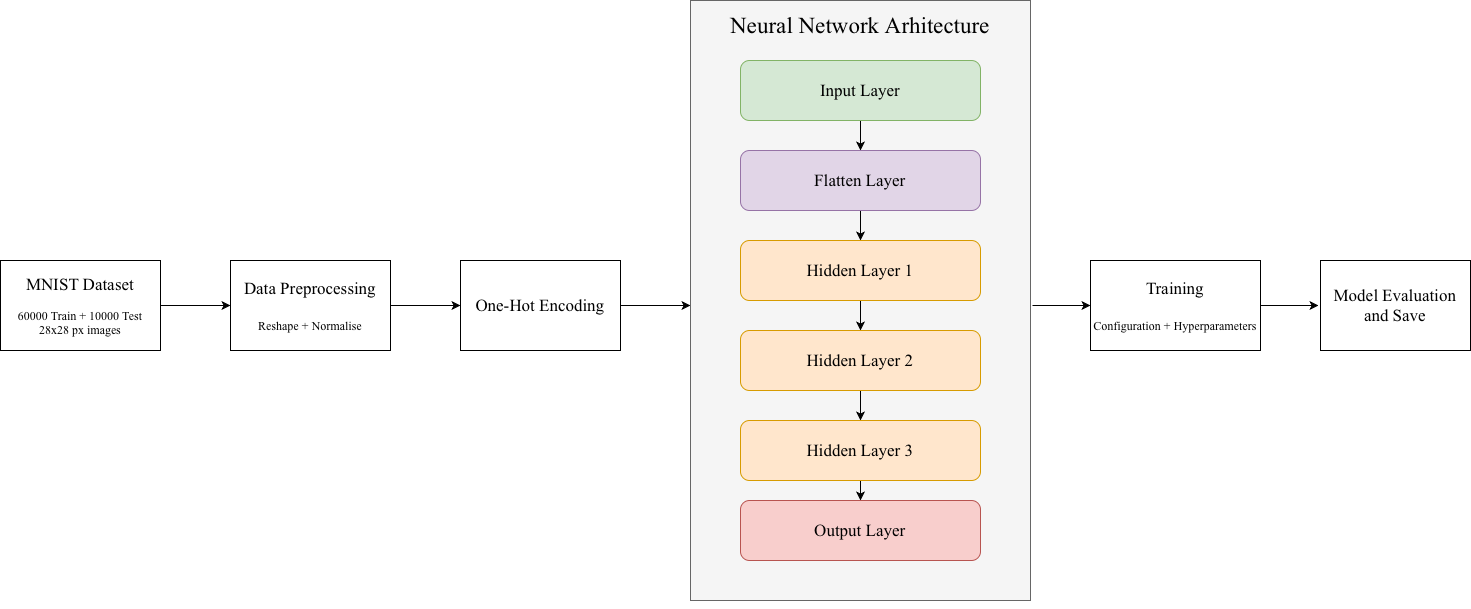

In [1]:
from IPython.display import display, Image 
display(Image(filename='Diagram.png', width=1200))

#### 2. Recognizing digits by training on MNIST dataset

##### Dataset overview
This implementation uses the **MNIST (Modified National Institute of Standards and Technology) dataset**, a standard dataset widely used for training and evaluating handwritten digit recognition models. The dataset contains 70,000 grayscale images of handwritten digits (0-9) collected from American Census Bureau employees and high school students. [14]

##### Data source
The dataset is obtained directly through Keras's built-in datasets module, which automatically downloads and caches the data locally on first use. This eliminates the need for manual data acquisition or external file management.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Tensorflow
import tensorflow as tf
import keras
from keras import Model
from keras.datasets import mnist
from keras.layers import Dense, Flatten, Input
from keras import utils

tf.keras.backend.set_floatx('float64')

##### Step 1: Loading train and test data from MNIST

##### Input data type
- **Data Type:** Image data (2D grayscale images)
- **Structure:** The input consists of a collection of static images, **not graphs or time series data**
- **Domain:** Computer vision / image classification

In [3]:
# Loading the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Displaying the shape of the dataset
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (60000, 28, 28) y_train: (60000,)
X_test : (10000, 28, 28) y_test : (10000,)


### Input data format

The MNIST dataset is divided into training and test sets:

**Training set:**
- **Images:** 60000 grayscale images (28×28 pixels)
- **Labels:** 60000 integer labels (digits 0-9)
- **Shape:** Images array has shape *(60000, 28, 28)*, labels array has shape *(60000,)*

**Test set:**
- **Images:** 10000 grayscale images (28×28 pixels)
- **Labels:** 10000 integer labels (digits 0-9)
- **Shape:** Images array has shape *(10000, 28, 28)*, labels array has shape *(10000,)*

**Pixel value range:**
- Original pixel intensities range from **0 (black) to 255 (white)**
- Data type: 8-bit unsigned integers 
- Each image is represented as a 28×28 matrix of these intensity values

##### Required pre-processing steps
To prepare the MNIST data for CNN training, several pre-processing transformations must be applied:

##### 1. **Normalization**
- Scale pixel values by dividing by 255 ([0, 255] -> [0, 1])
- Pixel values become numbers between 0 and 1

##### 2. **Reshaping for CNN input**
- Add a channel dimension to convert from shape *(samples, 28, 28)* to *(samples, 28, 28, 1)*
- We need the input to be a grayscale image (1 channel), not RGB image (3 channels) 

##### 3. **Label encoding (One-Hot Encoding)**
- Convert integer labels to binary class matrices
- Each label becomes a vector of length 10 (one position for each digit class)

In [4]:
# Preprocessing the data
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype(np.float64) / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype(np.float64) / 255

# Displaying the shape of the labels after preprocessing
print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (60000, 28, 28, 1) X_test: (10000, 28, 28, 1)


Convert y_train and y_test to categorical

In [5]:
# One-hot encoding the labels
y_train = utils.to_categorical(y_train)
y_test = utils.to_categorical(y_test)

# Displaying the shape of the labels after one-hot encoding
print("y_train:", y_train.shape, "y_test:", y_test.shape)

y_train: (60000, 10) y_test: (10000, 10)


##### Pre-processing summary

| Pre-processing Step | Input Format | Output Format | Purpose |
|---------------------|--------------|---------------|---------|
| **Normalization** | Pixel values [0, 255] | Pixel values [0, 1] | Faster convergence, numerical stability |
| **Reshaping** | Shape: (samples, 28, 28) | Shape: (samples, 28, 28, 1) | Match CNN input requirements |
| **Label Encoding** | Integer labels (0-9) | One-hot vectors (length 10) | Compatible with categorical loss function |

After applying these pre-processing steps, the data is properly formatted and ready to be fed into the CNN model for training and evaluation.

##### Step 2: Display some images from dataset

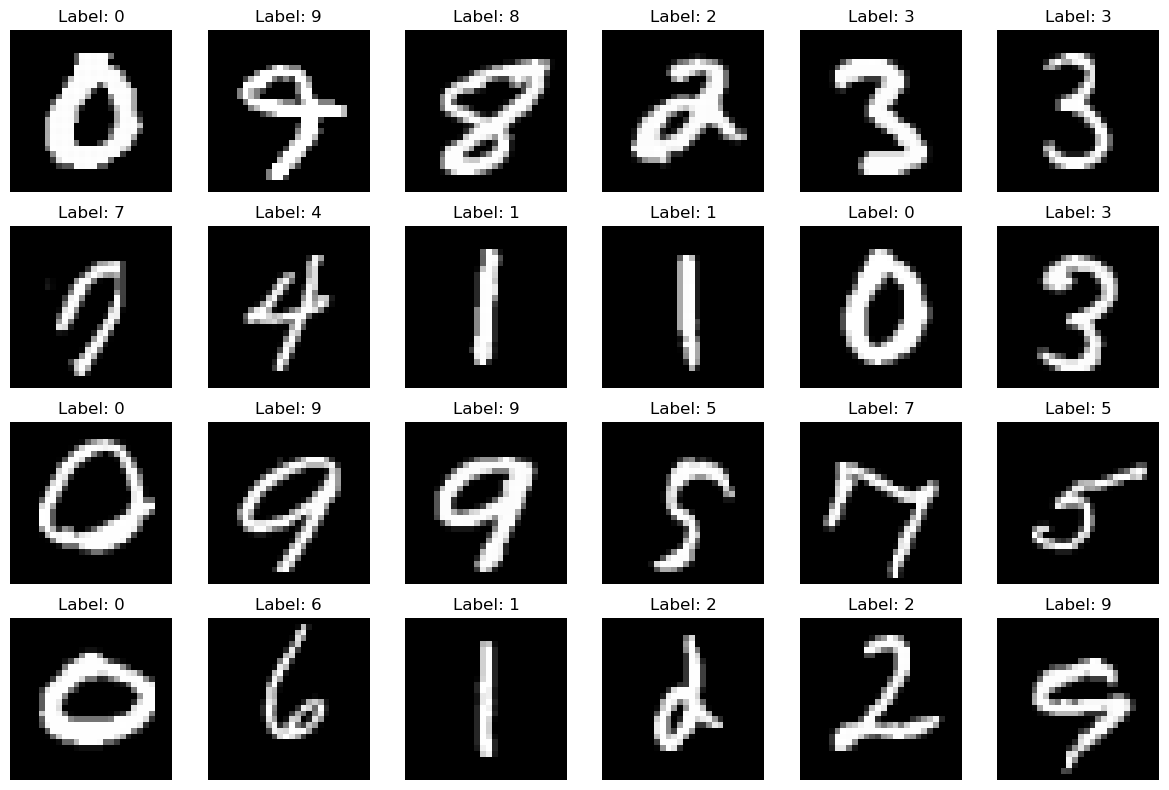

In [6]:
# Create a 6x4 grid
fig, axes = plt.subplots(4, 6, figsize=(12, 8))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Get 24 random indices (4 * 6 = 24 images)
random_indices = np.random.choice(len(X_train), size=24, replace=False)

# Display each image
for i, ax in enumerate(axes):
    idx = random_indices[i]
    ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[idx].argmax()}')
    ax.axis('off')  # Hide axes

plt.tight_layout()
plt.show()

##### Step 3: Prepare CNN

By trial and error, a CNN consisting in 4 layers has been choosen:
- 3 hidden layers x 16 neurons
- final layer of 10 neurons

##### Layer-by-layer structure

**1. Input layer**
- Shape: *(28, 28, 1)* - needs 28×28 grayscale images

**2. Flatten layer**
- Converts the 2D image *(28, 28, 1)* into a 1D vector of 784 features
- Required because Dense layers need flat input

**3. Three hidden dense layers**
- Each has 16 neurons with ReLU activation
- Learn increasingly abstract feature representations
- ReLU (Rectified Linear Unit) introduces non-linearity for complex pattern learning

**4. Output layer**
- 10 neurons (one per digit class: 0-9)
- No activation specified (linear output produces raw scores/logits)

In [7]:
# Building the CNN model
input_img = Input(shape=(28, 28, 1))
model = keras.layers.Flatten()(input_img)
model = Dense(16, activation = 'relu')(model)
model = Dense(16, activation = 'relu')(model)
model = Dense(16, activation = 'relu')(model)
model = Dense(10)(model)

# Creating the model
model = Model(inputs=input_img, outputs=model)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 16)                12560     
                                                                 
 dense_1 (Dense)             (None, 16)                272       
                                                                 
 dense_2 (Dense)             (None, 16)                272       
                                                                 
 dense_3 (Dense)             (None, 10)                170       
                                                                 
Total params: 13,274
Trainable params: 13,274
Non-trainable p

Compile and train the model

In [8]:
# Compiling and training the model
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
model.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=200, verbose=2)

Epoch 1/100


2025-12-28 17:40:27.235804: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


300/300 - 0s - loss: 0.1018 - accuracy: 0.0963 - val_loss: 0.0926 - val_accuracy: 0.1292 - 450ms/epoch - 2ms/step
Epoch 2/100
300/300 - 0s - loss: 0.0901 - accuracy: 0.1499 - val_loss: 0.0879 - val_accuracy: 0.1811 - 209ms/epoch - 696us/step
Epoch 3/100
300/300 - 0s - loss: 0.0868 - accuracy: 0.2075 - val_loss: 0.0851 - val_accuracy: 0.2566 - 210ms/epoch - 700us/step
Epoch 4/100
300/300 - 0s - loss: 0.0842 - accuracy: 0.2793 - val_loss: 0.0825 - val_accuracy: 0.3359 - 216ms/epoch - 721us/step
Epoch 5/100
300/300 - 0s - loss: 0.0819 - accuracy: 0.3585 - val_loss: 0.0801 - val_accuracy: 0.4100 - 211ms/epoch - 704us/step
Epoch 6/100
300/300 - 0s - loss: 0.0796 - accuracy: 0.4258 - val_loss: 0.0779 - val_accuracy: 0.4635 - 211ms/epoch - 704us/step
Epoch 7/100
300/300 - 0s - loss: 0.0775 - accuracy: 0.4725 - val_loss: 0.0759 - val_accuracy: 0.5020 - 210ms/epoch - 701us/step
Epoch 8/100
300/300 - 0s - loss: 0.0756 - accuracy: 0.5054 - val_loss: 0.0740 - val_accuracy: 0.5322 - 210ms/epoch - 6

## Part D – Software Testing and Evaluation

##### Step 4: Evaluate model

The model was evaluated on a subset of the test dataset (10000 samples from indices 30-200).

- **Loss** - Measures how well the model's predictions match the actual labels. Lower values indicate better performance.
- **Accuracy** - Represents the percentage of correctly classified samples in the test set.

In [9]:
# Evaluating the model
model.evaluate(x=X_test[30:200], y=y_test[30:200])

6/6 [==============================] - 0s 636us/step - loss: 0.0281 - accuracy: 0.8706


[0.02811938535117342, 0.8705882352941177]

##### Step 5: Save the model

In [10]:
# Saving the model
model.save('mnist_dnn_model.keras')

##### Interpretation of results

**Digit recognition:**

The model's performance demonstrates good accuracy (87%) in recognizing handwritten digits from the MNIST dataset.

**Real-world applications:**
- Automated postal code recognition systems
- Bank check processing systems
- Educational applications could provide instant feedback on handwritten digit exercises

##### Strengths of the implementation

1. **Simplicity and Efficiency:** 
- Lightweight architecture good for fast training
- Can run on CPU 
- Easy to understand and modify

2. **Dataset:** 
- MNIST is a well-known and easy to access dataset
- Clean data that ensures reliable training

3. **Fast inference:** 
- Small model size enables real-time predictions

##### Limitations of the implementation

1. **Limited generalization:**
- Trained only on MNIST's specific handwriting style
- May not perform well on different handwriting datasets or real-world images

2. **Small model capacity:**
- Only 16 neurons per hidden layer may be insufficient for complex pattern recognition
- May underfit on more challenging datasets

3. **Not ready for production:**
- No error handling or confidence thresholds
- No consideration for adversarial examples

## Part E - Equity, Diversity, Inclusion (EDI) and Sustainability

### Bias and Fairness
While the MNIST dataset is standard for handwriting recognition, fairness issues persist regarding how models handle stylistic variations. Convolutional Neural Networks function as "black boxes" that learn patterns based on the connection between pixels. By learning patterns specific to the training data's handwriting styles, the model can achieve high accuracy on similar inputs. However, this specialization creates bias against handwriting styles not well-represented in MNIST, potentially disadvantaging users whose writing differs from the dataset's predominant styles.

### Accessibility and Inclusion
MNIST dataset is a common publicly available dataset due to its earlt standart benchmark and clean data. Although modern neural networks demand high computational power, the models developed on MNIST allow training on standard CPU-based hardware. Additionally, by designing the CNN from scratch rather than relying on large pretrained models, it avoids dependency on more computational power.

### Ethical Implications
The deployment of digit recognition systems extends into high-stakes applications such as Optical Character Recognition (OCR) for document digitization and automated data entry. In these operational contexts, errors and biases may unfairly penalize individuals with atypical handwriting styles. While this implementation is considered low-risk, deploying similar models would require transparency about limitations.

### Environmental Sustainability
The environmental impact of the proposed CNN is low compared to large deep learning models. The MNIST dataset consists of small grayscale images (28×28 pixels), and the custom CNN architecture is small, therefore needing lower computational power. Additionally, the dataset automatically downloads and cashes the data locally. This resulting in no need for manual data aquisition.

## Aditional Research - Cracking the AI - Attacking the Neural Network Model

The foundational research establishes that extracting the parameters of a deep neural network (DNN) is mathematically analogous to the cryptanalysis of block ciphers, where the model's weights serve as a secret key. By analyzing the network as a linear function, researchers demonstrated that the boundaries between different regions, known as "Critical Points", act as side-channels that leak information about the model's internal structure. [11] In this framework, an attacker queries the model to locate these specific inputs, allowing them to recover the "signature" of neurons, which reveals the weights up to a scalar multiplication. However, this initial approach faced a significant computational struggle known as "Sign Recovery," which often required an extremely long time to determine if the sign was positive or negative. [11]


Following advancements addressed these computational limitations to achieve extraction in polynomial time, meaning the attack remains fast even as the network grows larger. The introduction of a technique called "Neuron Wiggle" allowed researchers to efficiently solve the sign recovery problem without resorting to brute force.[12] By applying small, targeted perturbations to the inputs, attackers can statistically measure how these changes propagate through the network; if the perturbation is "blocked" by a Rectified Linear Unit (ReLU), the neuron is inactive (negative sign), whereas if it passes through to the output, the neuron is active (positive sign). This innovation reduced the time required to extract large neural networks, such as those used for CIFAR-10 image classification, from theoretically impossible timeframes to minutes.[12]


The most recent findings of these attack targets the "hard-label" setting, a highly restrictive scenario where the model reveals only the final class decision (e.g., "cat" or "dog") rather than precise numerical probability scores. To overcome the lack of detailed numerical feedback, attackers utilize "Dual Points", which are specific inputs located at the intersection of a decision boundary and a neuron's critical hyperplane.[13] By tracing the geometric shape of the decision boundaries and analyzing where they bend or change orientation, attackers can infer the internal parameters of the network even without access to the model's confidence scores. This demonstrates that concealing the model's internal probabilities is an insufficient defense, as the geometric structure of the decision boundary alone contains enough information to allow for the complete mathematical reconstruction of the model.[13]

#### Use Case - Knowing the dataset and the model type, as well as all weights and biases of the output layer, we want to extract the weights and biases of neurons from the first layer

This implementation follows the research study made by [Nicholas Carlini et all: **Cryptanalytic Extraction of Neural Network Models**](https://arxiv.org/pdf/2003.04884) which redefines the task of model extraction as a cryptanalytic problem, effectively treating the neural network as an encryption function where the internal weights and biases serve as the "secret key".

#### Attack methodology

**Core principle:**
The attack leverages the fact that ReLU networks create piecewise linear decision boundaries. At points where the network transitions between linear regions (critical points), specific neurons activate or deactivate, revealing information about their weight configurations.

**Attack process:**
1. **Image morphing:** Generate a linear path between two random test images by computing *x(ε) = x_start + ε(x_end - x_start)* where ε ∈ [0,1]
2. **Critical point detection:** Identify points along the morphing path where the network's output function changes slope (indicating neuron activation changes)
3. **Signature extraction:** At each critical point, compute the weight signature (normalized weight ratios w_i/w_1) of the toggled neuron using numerical differentiation
4. **Neuron matching:** Compare extracted signatures against actual model weights to identify which neurons were successfully extracted

##### Step 1: Load mnist_dnn_model

In [11]:
# Loading the previously saved model
mnist_model = keras.models.load_model('mnist_dnn_model.keras')

# X_train, X_test, y_train, y_test variables are assumed to be already defined as per previous code cells
OUTPUT_NUMBER = 0

##### Step 2: Define BlackBox class
A class for analyzing neural network functions, including finding critical points and computing signatures.

In [12]:
class BlackBox:

# --------------------------------------------------------------------------------
    @staticmethod
    def isLinear(func, x_low, x_upp, eps=1e-4, tol=1e-10, debug=False):
        """
        Determines if a function is linear in a given closed interval.

        Parameters
        ----------
        func
            The function. func takes as input a real number (float) and outputs a
            real number (float).
        x_low : float
            Lower bound of the interval.
        x_upp : float
            Upper bound of the interval.
        eps : float, optional
            "Infinitesimal" variation used when computing slopes and derivatives.
        tol : float, optional
            Tolerance to decide if two real numbers (floats) are "equal".
        debug : bool, optional
            Specifies whether debug information is printed to standard output.

        Returns
        -------
        bool
            True if the function is linear in the given interval, False otherwise.
        """
        

        # Check whether x_low and x_upp are too close
        if (np.abs(x_upp - x_low) < tol):
            if debug:
                print(" LIN: Points are too close to each other")
            return None
        
        x_mid = (x_low + x_upp) / 2
        
        # Value of func at x_low, x_upp and x_mid
        y_low = func(x_low)
        y_upp = func(x_upp)
        y_mid = func(x_mid)
        
        # Expected value of func at x_mid
        y_mid_exp = (y_low + y_upp) / 2

        
        # Check (i) f(x_mid) = (f(x_low) + f(x_upp)) / 2
        if (np.abs(y_mid - y_mid_exp) > tol):
            if debug:
                print(f"LIN: Tolerance is {tol}")
                print(" returning False ")
                print(" ")
            return False

        # Slopes of L_low and L_upp
        m_low = (func(x_low + eps) - y_low) / eps
        m_upp = (y_upp - func(x_upp - eps)) / eps


        # Check (ii) L_low = L_upp
        if (np.abs(m_low - m_upp) > tol):
            return False
        
        # Slopes of L_mid_low and L_mid_upp
        m_mid_low = (y_mid - func(x_mid - eps)) / eps
        m_mid_upp = (func(x_mid + eps) - y_mid) / eps
        
        # Check (ii) L_mid_low = L_low and L_mid_upp = L_upp
        if (np.abs(m_mid_low - m_low) > tol) or (np.abs(m_mid_upp - m_upp) > tol):
            return False
        
        return True

# --------------------------------------------------------------------------------  
    @staticmethod
    def findCriticalPoints(func, x_low, x_upp, eps=1e-7, tol=5e-8, debug=False):
        """
        Finds critical points of a function in a given interval.

        Parameters
        ----------
        func
            The function to analyze.
        x_low : float
            Lower bound of the interval.
        x_upp : float
            Upper bound of the interval.
        eps : float, optional
            "Infinitesimal" variation used when computing slopes and derivatives.
        tol : float, optional
            Tolerance for numerical comparisons.
        debug : bool, optional
            Specifies whether debug information is printed to standard output.

        Returns
        -------
        list of float
            List of critical points found in the interval.
        """

        # Check whether the interval is linear under func (i.e., no critical points)
        isLin = BlackBox.isLinear(func, x_low, x_upp, eps=eps, tol=tol, debug=debug)
        
        if (isLin == None):
            # Points close to each other (see isLinear())
            return []
        elif (isLin):
            if debug:
                print("No critical point (same line)")
            return []
        
        # Value of func at x_low and x_upp
        y_low = func(x_low)
        y_upp = func(x_upp)

        
        # Slopes for the lines:
        #    * L_low (passing through x_low), and
        #    * L_upp (passing through x_upp)
        m_low = (func(x_low + eps) - y_low) / eps
        m_upp = (y_upp - func(x_upp - eps)) / eps

        
        # Following Jagielski et al. 2019, compute the x coordinate of the point
        # where L_low and L_upp intersect,
        aux = (y_upp - y_low - (x_upp - x_low) * m_upp) / (m_low - m_upp) 
        x_int = x_low + aux
        # the expected value of func at that point
        y_exp = y_low + m_low * aux
        # and the real value of func at the same point
        y_int = func(x_int)

        
        # Derivatives of func at x_int
        df_l = (y_int - func(x_int - eps)) / eps
        df_r = (func(x_int + eps) - y_int) / eps
        
        # If f_int == f_exp, df_l != df_r and x_low <= x_int <= x_upp, the only
        # critical point is x_int.
        if (np.abs(y_exp - y_int) < tol and np.abs(df_l - df_r) > tol and x_low <= x_int and x_int <= x_upp):
            if debug:
                print(f"fcp: Found {x_int}")
            return [ x_int ]

        if debug:
            print("FCP: More than one critical point")

        # More than one critical point; check left and right side of the interval
        x_mid = (x_low + x_upp) / 2
        
        critical_point = BlackBox.findCriticalPoints(func, x_low, x_mid, eps=eps, tol=tol, debug=debug)
        critical_point = critical_point + BlackBox.findCriticalPoints(func, x_mid, x_upp, eps=eps, tol=tol, debug=debug)

        return critical_point

# --------------------------------------------------------------------------------
    @staticmethod
    def getSignatureFirstHiddenLayer(func, x, eps1=5e-4, eps2=5e-5):
        """
        Finds the signature of the neuron corresponding to the given critical point.

        The signature of a neuron is

            (w_1 / w_1, w_2 / w_1, ..., w_n / w_1),

        where w_i, i = 1, ..., n, are the weights of the incoming connections to
        the neuron.

        Parameters
        ----------
        func
            The DNN. func must handle vectorised inputs, i.e., on input
            [x_1, ..., x_n], it must return [DNN(x_1), ..., DNN(x_n)].
        x : array
            Critical point used to compute the signature of its corresponding
            neuron.
        eps1 : float, optional
            Small variation used for exploring the neighbourhood of the critical
            point.
        eps2 : float, optional
            "Infinitesimal" variation used when computing the partial derivatives.

        Returns
        -------
        list of float
            Signature of the neuron corresponding to the given critical point.
        """
        n = np.prod(x.shape)

        # Canonical basis
        basis = np.identity(n, dtype=np.double).reshape((n,) + x.shape)
        # Copy x n times
        x = np.full((n,) + x.shape, x)

        # Compute difference of partial derivatives without division by eps2;
        # the latter is not needed because it cancels out when dividing by
        # alpha_1 = \partial f(x) / \partial e_1
        alpha = np.abs(func(x + eps1 * basis) - func(x + (eps1 - eps2) * basis) -\
                       func(x - eps1 * basis) + func(x - (eps1 + eps2) * basis))

        # Compute the vectors e_1 + e_i, i = 1, ..., n
        basis = basis + basis[0]
        # and the difference of partial derivatives (without division by eps2) to
        # determine the signs of the coordinates
        aux = np.abs(func(x + eps1 * basis) - func(x + (eps1 - eps2) * basis) -\
                     func(x - eps1 * basis) + func(x - (eps1 + eps2) * basis))
        # Sign of a coordinate:  1, if |alpha_{1,i}| =  |alpha_1| + |alpha_i|
        #                       -1, if |alpha_{1,i}| = ||alpha_1| - |alpha_i||
        diff_n = np.abs(np.abs(alpha - alpha[0]) - aux)
        diff_p = np.abs(np.abs(alpha + alpha[0]) - aux)
        signs = 1 - 2 * (diff_n < diff_p).astype(int)

        # Compute ratios of differences of partial derivatives
        return (alpha / alpha[0]) * signs

# --------------------------------------------------------------------------------
    @staticmethod
    def getLocalMatrixAndBias(x, weights, biases, numLayers, finalRelu=False, tol=1e-15):
        """
        Computes the local linear approximation of a neural network at a given point.

        Parameters
        ----------
        x : array
            Point at which to compute the local approximation.
        weights : list of arrays
            Weight matrices for each layer.
        biases : list of arrays
            Bias vectors for each layer.
        numLayers : int
            Number of layers.
        finalRelu : bool, optional
            Whether to apply ReLU to the final layer.
        tol : float, optional
            Tolerance for determining active neurons.

        Returns
        -------
        tuple
            (M, b, y) where M is the local Jacobian matrix, b is the bias term,
            and y is the output at x.
        """
        M = np.eye(np.prod(x.shape))
        b = np.zeros_like(x)
        y = x
        
        for i in range(numLayers):
            M = np.matmul(M, weights[i])
            b = np.matmul(b, weights[i]) + biases[i]
            y = np.matmul(y, weights[i]) + biases[i]
            if (i < (numLayers - 1)) or finalRelu:
                mask = (y > 0) & (y > tol)
                M *= mask[np.newaxis, :]
                b *= mask
                y *= mask
        
        return M, b, y

# --------------------------------------------------------------------------------
    @staticmethod
    def getSignature(func, weights, biases, x, eps1=5e-4, eps2=5e-5):
        """
        Computes the signature of a neuron at a critical point using random directions.

        Parameters
        ----------
        func
            The neural network function.
        weights : list of arrays
            Weight matrices for each layer.
        biases : list of arrays
            Bias vectors for each layer.
        x : array
            Critical point at which to compute the signature.
        eps1 : float, optional
            Small variation for exploring the neighborhood.
        eps2 : float, optional
            "Infinitesimal" variation for computing derivatives.

        Returns
        -------
        array
            Normalized signature vector.
        """
        M, b, h = BlackBox.getLocalMatrixAndBias(x, weights, biases, len(weights), finalRelu=True)
        ns = np.sum(h > 0) + 2 if len(weights) > 0 else np.prod(x.shape)
        
        # Random directions d_j
        d = np.sign(np.random.normal(0, 1, size=(ns,) + x.shape))
        x = np.full((ns,) + x.shape, x)  # Copy x
        
        # Compute difference of partial derivatives without division by eps2;
        # the latter is not needed because it cancels out when dividing by
        # alpha_1 = \partial f(x) / \partial e_1
        alpha = np.abs(func(x + eps1 * d) - func(x + (eps1 - eps2) * d) -\
                       func(x - eps1 * d) + func(x - (eps1 + eps2) * d))
        
        # Compute the vectors d_1 + d_i, i = 1, ..., n
        dd = d + np.full((ns,) + d[0].shape, d[0])
        # and the difference of partial derivatives (without division by eps2) to
        # determine the signs of the coordinates
        aux = np.abs(func(x + eps1 * dd) - func(x + (eps1 - eps2) * dd) -\
                     func(x - eps1 * dd) + func(x - (eps1 + eps2) * dd))

        # Sign of a coordinate:  1, if |alpha_{1,i}| =  |alpha_1| + |alpha_i|
        #                       -1, if |alpha_{1,i}| = ||alpha_1| - |alpha_i||
        diff_n = np.abs(np.abs(alpha - alpha[0]) - aux)
        diff_p = np.abs(np.abs(alpha + alpha[0]) - aux)
        signs = 1 - 2 * (diff_n < diff_p).astype(int)
        
        y = alpha * signs
        h = np.matmul(d, M)
        
        sol, _, _, _ = np.linalg.lstsq(h, y, rcond=None)
        
        return sol / sol[0]


##### Step 3: Define WhiteBox class
A class for analyzing neural network models with direct access to weights and biases. Provides methods for extracting model internals and analyzing neuron behavior. This class is used for verification of neuron weights and biases.

In [13]:
class WhiteBox:
    
    @staticmethod
    def getWeightsAndBiases(model, layerID):
        """
        Extracts weights and biases from a specific layer of the model.

        Parameters
        ----------
        model
            The neural network model (Keras/TensorFlow model).
        layerID : int
            Index of the layer to extract weights and biases from.

        Returns
        -------
        tuple
            (weights, biases) where weights is the transposed weight matrix
            and biases is the bias vector as numpy arrays.
        """
        weights, biases = model.get_layer(index=layerID).get_weights()
        return np.array(weights).transpose(), np.array(biases)

# --------------------------------------------------------------------------------
    @staticmethod
    def getSignaturesAndBiases(model, layerID):
        """
        Computes normalized signatures and biases for all neurons in a layer.

        The signature of a neuron is the weight vector normalized by its first component:
        (w_1 / w_1, w_2 / w_1, ..., w_n / w_1)

        Parameters
        ----------
        model
            The neural network model (Keras/TensorFlow model).
        layerID : int
            Index of the layer to extract signatures from.

        Returns
        -------
        tuple
            (signatures, normalized_biases) where signatures is an array of normalized
            weight vectors and normalized_biases are the biases divided by the first
            weight component.
        """
        weights, biases = WhiteBox.getWeightsAndBiases(model, layerID)
        signatures = np.array([row / row[0] for row in weights])
        return signatures, biases / weights[:, 0]

# --------------------------------------------------------------------------------
    @staticmethod
    def getLayerOutputs(model, testInput, onlyLayerID=None):
        """
        For a neural network model, collect the intermediate outputs for a test input.
        
        If onlyLayerID is equal to None, collect the intermediate output of all layers.
        To collect the values of a particular layer, onlyLayerID must be set to the
        layer identified by its `layerID` in model.layers.

        Parameters
        ----------
        model
            The neural network model (Keras/TensorFlow model).
        testInput : array
            Input data to pass through the model.
        onlyLayerID : int, optional
            If specified, only return outputs for this layer. Otherwise return all layers.

        Returns
        -------
        list or array
            List of outputs for all layers, or single array if onlyLayerID is specified.
        """
        outputOfAllLayers = []

        for layerID, layer in enumerate(model.layers):
            
            if onlyLayerID is not None and layerID != onlyLayerID:
                continue

            intermediateLayerModel = Model(inputs=model.input, 
                                          outputs=model.get_layer(layer.name).output)
            intermediateOutput = intermediateLayerModel.predict(testInput)
            outputOfAllLayers.append(intermediateOutput)
            
        if onlyLayerID is not None:
            outputOfAllLayers = outputOfAllLayers[0]

        return outputOfAllLayers

# --------------------------------------------------------------------------------
    @staticmethod
    def findToggledNeuronsInLayer(model, layerID, interpolatedImages, debug=False):
        """
        For a given model find the toggled neurons in layer layerID when moving through
        the interpolatedImages.
        
        Get the `interpolatedImages` by using (for example) the function
        `getInterpolatedImages`.

        Parameters
        ----------
        model
            The neural network model (Keras/TensorFlow model).
        layerID : int
            Index of the layer to analyze.
        interpolatedImages : array
            Sequence of interpolated images to test for neuron toggling.
        debug : bool, optional
            If True, print debug information.

        Returns
        -------
        array
            An array that contains in which of the `n` steps which neuron was toggled.
            For example, the following output means that first neuron 12 was toggled
            in step 3007:
            array([[3007,   12],
                   [6103,   19],
                   [7742,    4],
                   [8067,    2],
                   [9543,   15],
                   [9556,   15],
                   [9557,   15]])
        """
        
        # Get layer outputs for interpolated images
        outputLayer = WhiteBox.getLayerOutputs(model, interpolatedImages, 
                                              onlyLayerID=layerID)
        
        # Analyze activity and toggling
        activeInLayer = (outputLayer > 0).astype(int)    # find if the neuron was active or not
        toggled = np.diff(activeInLayer, axis=0)         # find toggling points for each neuron (axis=0)
        if debug:
            print(toggled)
        
        # Return which neuron was toggled in which step
        toggledStepNeuron = np.argwhere((toggled == 1) | (toggled == -1))
        return toggledStepNeuron

# --------------------------------------------------------------------------------
    @staticmethod
    def checkRecoveredSignature(model, layerID, neuronID, signature, tolerance=5e-7):
        """
        Verifies that a recovered signature matches the actual neuron weights.

        Compares a recovered signature against the actual normalized weights of a
        specific neuron, checking both sign agreement and numerical accuracy.

        Parameters
        ----------
        model
            The neural network model (Keras/TensorFlow model).
        layerID : int
            Index of the layer containing the neuron.
        neuronID : int
            Index of the neuron to check.
        signature : array
            The recovered signature to verify.
        tolerance : float, optional
            Numerical tolerance for comparing signature values.

        Returns
        -------
        None
            Prints error messages if discrepancies are found.
        """
        # Get real ratios of weights (i.e., real signature)
        signature_wb, _ = WhiteBox.getSignaturesAndBiases(model, layerID)
        signature_wb = signature_wb[neuronID]
        
        # Check signs of coordinates of the signature
        diff_sign = np.logical_xor(signature_wb > 0, signature > 0)
        if np.any(diff_sign):
            diff_sign_ids = np.argwhere(diff_sign == True)
            print(diff_sign_ids.shape)
            print(f'Error: Difference in signs: {diff_sign_ids.flatten()}')
        
        # Check numerical difference of coordinates of the signature
        diff = np.abs(signature_wb - signature)
        if np.any(diff > tolerance):
            diff_ids = np.argwhere(diff > tolerance)
            print(f'Error: Difference greater than {tolerance}: {diff_ids.flatten()}; max difference {np.max(diff)}')

##### Step 4: Define methods for finding critical points from a pair of images

In [14]:
# --------------------------------------------------------------------------------
def dnn(x):
    return mnist_model(np.array([x]), training=False).numpy()[0][OUTPUT_NUMBER]

# --------------------------------------------------------------------------------
def dnn_vec(x):
    return mnist_model.predict(x, verbose=0)[:,OUTPUT_NUMBER]

# --------------------------------------------------------------------------------
def morph(x1, x2, eps):
    return x1 + eps * (x2 - x1)

# --------------------------------------------------------------------------------
def findCriticalPointsFromPairOfImages(x_ini, x_end, eps=1e-7, tol=5e-8, debug=False):
    def gamma(e):
        return dnn(morph(x_ini, x_end, e))
    critPts = BlackBox.findCriticalPoints(gamma, 0.0, 1.0, eps=eps, tol=tol, debug=debug)    
    return [morph(x_ini, x_end, critPt) for critPt in critPts]

##### Step 5: Define methods for extracting weights of neurons from first hidden layer

In [15]:
# --------------------------------------------------------------------------------
def matchSignatures(extracted_sig, actual_sigs, tolerance=1e-5):
    """
    Try to match an extracted signature against actual neuron signatures.
    
    Returns the neuron ID if a match is found, otherwise None.
    """
    for neuron_id, actual_sig in enumerate(actual_sigs):
        if np.allclose(extracted_sig.flatten(), actual_sig, rtol=tolerance, atol=tolerance):
            return neuron_id
    return None

# --------------------------------------------------------------------------------
def extractAndPrintWeights(num_pairs=10, num_neurons=10):
    """
    Extract and print weight signatures for neurons in the first hidden layer.
    
    Parameters:
    -----------
    num_pairs : int
        Number of random image pairs to analyze
    num_neurons : int
        Number of neurons to attempt to extract
    """
    print("="*80)
    print("EXTRACTING WEIGHT SIGNATURES FROM FIRST HIDDEN LAYER")
    print("="*80)
    
    # Get actual weights from the model (whitebox - for verification only)
    W_actual, b_actual = WhiteBox.getWeightsAndBiases(model, 2)  # Layer 2 is first hidden layer
    signatures_actual, _ = WhiteBox.getSignaturesAndBiases(model, 2)
    
    # Store extracted signatures
    extracted_signatures = []
    matched_neurons = set()
    all_matches = []
    
    for pair_idx in range(num_pairs):
        # Pick random images
        x_ini = X_test[np.random.randint(1000),:,:,0]
        x_end = X_test[np.random.randint(1000),:,:,0]
        
        print(f"\n--- Image Pair {pair_idx + 1}/{num_pairs} ---")
        
        # Find critical points along the morph
        critical_points = findCriticalPointsFromPairOfImages(x_ini, x_end, debug=False)
        print(f"Found {len(critical_points)} critical points")
        
        # Extract signature for each critical point
        for cp_idx, cp in enumerate(critical_points[:num_neurons]):  # Limit to avoid too many
            # Get the signature (weight ratios)
            signature_bb = BlackBox.getSignatureFirstHiddenLayer(dnn_vec, cp)
            
            # Try to match this signature to a neuron
            matched_neuron = matchSignatures(signature_bb, signatures_actual)
            
            if matched_neuron is not None:
                status = "✓ MATCH!" if matched_neuron not in matched_neurons else "✓ (duplicate)"
                matched_neurons.add(matched_neuron)
                print(f"  CP {cp_idx + 1}: {status} -> Neuron {matched_neuron}")
                all_matches.append({
                    'pair': pair_idx,
                    'cp': cp_idx,
                    'neuron': matched_neuron,
                    'signature': signature_bb
                })
            else:
                print(f"  CP {cp_idx + 1}: ✗ No match found")
            
            # Store this signature
            extracted_signatures.append({
                'pair_idx': pair_idx,
                'cp_idx': cp_idx,
                'signature': signature_bb,
                'matched_neuron': matched_neuron
            })
    
    print("\n" + "="*80)
    print("EXTRACTION SUMMARY")
    print("="*80)
    print(f"Total critical points analyzed: {len(extracted_signatures)}")
    print(f"Unique neurons matched: {len(matched_neurons)} / {W_actual.shape[0]}")
    print(f"Matched neuron IDs: {sorted(matched_neurons)}")
    
    print("\n" + "="*80)
    print("VERIFICATION AGAINST ACTUAL MODEL WEIGHTS")
    print("="*80)
    
    print(f"\nActual weights shape: {W_actual.shape}")
    print(f"Actual biases shape: {b_actual.shape}")
    print(f"Number of neurons in first hidden layer: {W_actual.shape[0]}")
    
    if matched_neurons:
        print("\n--- Matched Neurons Details ---")
        for neuron_id in sorted(matched_neurons):
            print(f"\n✓ Neuron {neuron_id} - SUCCESSFULLY EXTRACTED!")
            print(f"  Signature (first 10 values out of {len(signatures_actual[neuron_id])}): {signatures_actual[neuron_id][:10]}")
            # Find which pair/cp extracted this
            for match in all_matches:
                if match['neuron'] == neuron_id:
                    print(f"  Found in: Pair {match['pair']+1}, Critical Point {match['cp']+1}")
                    break
    else:
        print("\n⚠ No neurons were successfully matched this run.")
        print("This is due to random image selection. Try:")
        print("  1. Increase num_pairs (e.g., 10 or 20)")
        print("  2. Increase num_neurons per pair (e.g., 10)")
        print("  3. Run multiple times")
    
    print("\n--- Sample of Actual Weight Signatures ---")
    # for i in range(min(3, W_actual.shape[0])):
    for i in range(W_actual.shape[0]):
        matched_status = "✓ EXTRACTED" if i in matched_neurons else "✗ Not found"
        print(f"\nNeuron {i}: [{matched_status}]")
        print(f"  Signature (first 10 values): {signatures_actual[i][:10]}")
    
    return extracted_signatures, (W_actual, b_actual, signatures_actual), matched_neurons


##### Step 6: Extract weights and print match neurons

In [16]:
extracted_sigs, actual_weights, matched = extractAndPrintWeights(num_pairs=10, num_neurons=10)

print("\n" + "="*80)
print("EXTRACTION COMPLETE")
print("="*80)
print("\nNote: Each extracted signature represents the weight ratios (w_i/w_1)")
print("for a neuron that was toggled at that critical point.")
print(f"\nSuccess rate: {len(matched)}/16 neurons extracted ({100*len(matched)/16:.1f}%)")

EXTRACTING WEIGHT SIGNATURES FROM FIRST HIDDEN LAYER

--- Image Pair 1/10 ---
Found 26 critical points
  CP 1: ✗ No match found
  CP 2: ✗ No match found
  CP 3: ✓ MATCH! -> Neuron 15
  CP 4: ✗ No match found
  CP 5: ✗ No match found
  CP 6: ✗ No match found
  CP 7: ✗ No match found
  CP 8: ✗ No match found
  CP 9: ✗ No match found
  CP 10: ✗ No match found

--- Image Pair 2/10 ---
Found 17 critical points
  CP 1: ✓ MATCH! -> Neuron 3
  CP 2: ✗ No match found
  CP 3: ✗ No match found
  CP 4: ✗ No match found
  CP 5: ✗ No match found
  CP 6: ✗ No match found
  CP 7: ✗ No match found
  CP 8: ✗ No match found
  CP 9: ✓ (duplicate) -> Neuron 15
  CP 10: ✗ No match found

--- Image Pair 3/10 ---
Found 28 critical points
  CP 1: ✗ No match found
  CP 2: ✗ No match found
  CP 3: ✗ No match found
  CP 4: ✗ No match found
  CP 5: ✗ No match found
  CP 6: ✓ MATCH! -> Neuron 7
  CP 7: ✗ No match found
  CP 8: ✗ No match found
  CP 9: ✗ No match found
  CP 10: ✗ No match found

--- Image Pair 4/10 

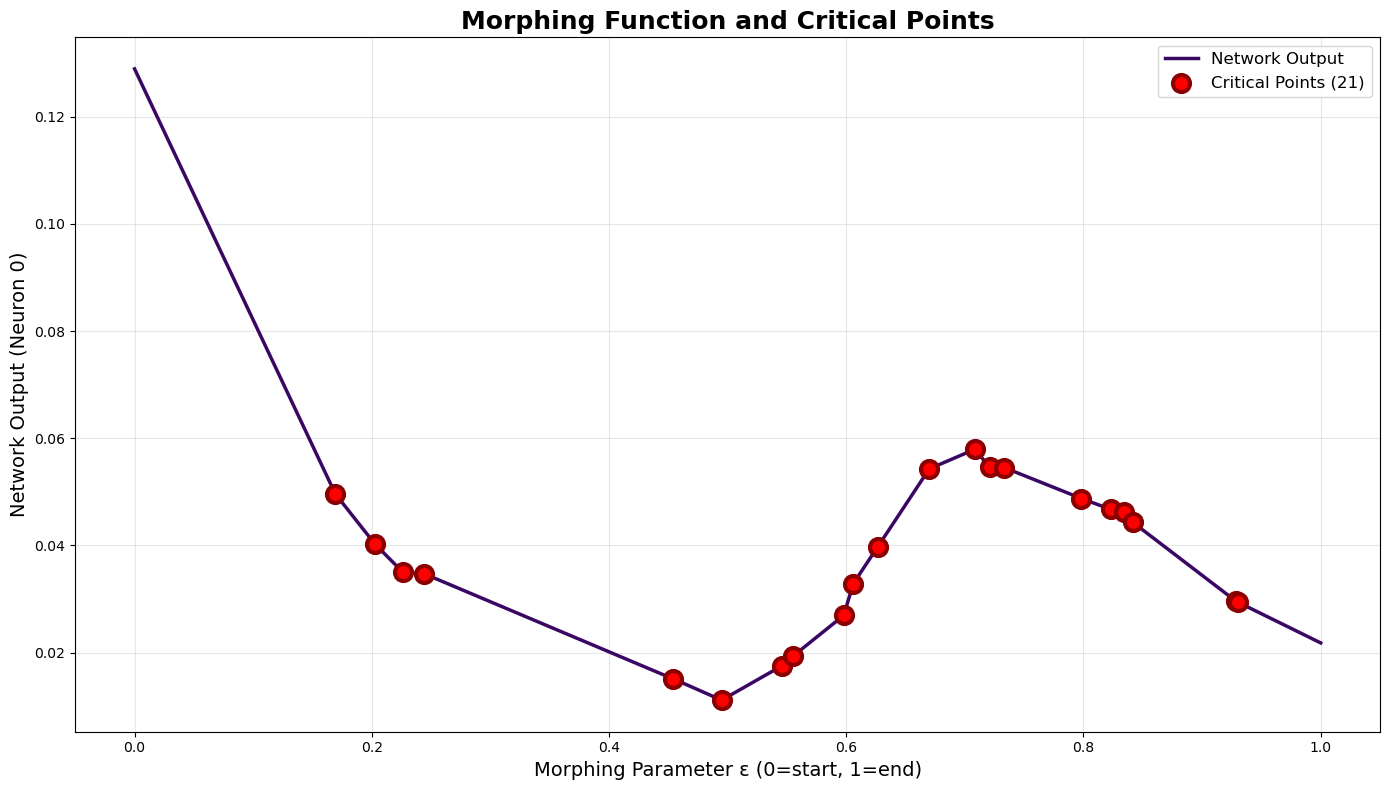


Found 21 critical points along the morphing path

Critical Points:
--------------------------------------------------
  1. ε = 0.169233, Output = 0.049626
  2. ε = 0.202519, Output = 0.040306
  3. ε = 0.226279, Output = 0.034981
  4. ε = 0.244419, Output = 0.034698
  5. ε = 0.454290, Output = 0.015109
  6. ε = 0.494926, Output = 0.011142
  7. ε = 0.545827, Output = 0.017559
  8. ε = 0.555221, Output = 0.019375
  9. ε = 0.597867, Output = 0.026961
  10. ε = 0.605963, Output = 0.032901
  11. ε = 0.626449, Output = 0.039708
  12. ε = 0.669994, Output = 0.054297
  13. ε = 0.708198, Output = 0.057926
  14. ε = 0.720919, Output = 0.054630
  15. ε = 0.733098, Output = 0.054540
  16. ε = 0.798091, Output = 0.048764
  17. ε = 0.823071, Output = 0.046744
  18. ε = 0.834387, Output = 0.046247
  19. ε = 0.841732, Output = 0.044297
  20. ε = 0.928400, Output = 0.029634
  21. ε = 0.930039, Output = 0.029442


In [17]:
from PIL import Image
from io import BytesIO

x_ini = X_test[np.random.randint(1000),:,:,0]
x_end = X_test[np.random.randint(1000),:,:,0]
steps=1000

def gamma_1(eps):
    return dnn(morph(x_ini, x_end, eps))
    
low = 0.0
upp = 1.0

# Get critical points
morph_bp_x = np.array(BlackBox.findCriticalPoints(gamma_1, low, upp, debug=False))
morph_bp_y = np.array([gamma_1(eps) for eps in morph_bp_x])

# Data points for plotting the function (optimized: use linspace, batch predict)
morph_eps = np.linspace(low, upp, steps)

# Create morphed images in batch (more memory efficient than list comprehension with array())
morph_x = x_ini[np.newaxis, :, :, np.newaxis] + \
            morph_eps[:, np.newaxis, np.newaxis, np.newaxis] * \
            (x_end - x_ini)[np.newaxis, :, :, np.newaxis]

# Batch prediction is much faster
morph_y = model.predict(morph_x, verbose=0)[:, OUTPUT_NUMBER]

# Filter critical points within bounds
valid_idx = (morph_bp_x >= low) & (morph_bp_x <= upp)
valid_bp_x = morph_bp_x[valid_idx]
valid_bp_y = morph_bp_y[valid_idx]

# Create the plot
plt.figure(figsize=(14, 8))  # Smaller, more reasonable size
plt.plot(morph_eps, morph_y, label='Network Output', color='#3b0764', linewidth=2.5)
plt.scatter(valid_bp_x, valid_bp_y, color='red', label=f'Critical Points ({len(valid_bp_x)})', 
            zorder=5, s=150, linewidth=3, edgecolors='darkred') 
plt.title('Morphing Function and Critical Points', fontsize=18, fontweight='bold')  
plt.xlabel('Morphing Parameter ε (0=start, 1=end)', fontsize=14) 
plt.ylabel(f'Network Output (Neuron {OUTPUT_NUMBER})', fontsize=14)  
plt.legend(fontsize=12) 
plt.grid(alpha=0.3)
plt.tight_layout()

# Display the chart
plt.show()

print(f"\nFound {len(valid_bp_x)} critical points along the morphing path")
print("\nCritical Points:")
print("-" * 50)
for i, (eps_val, y_val) in enumerate(zip(valid_bp_x, valid_bp_y)):
    print(f"  {i+1}. ε = {eps_val:.6f}, Output = {y_val:.6f}")

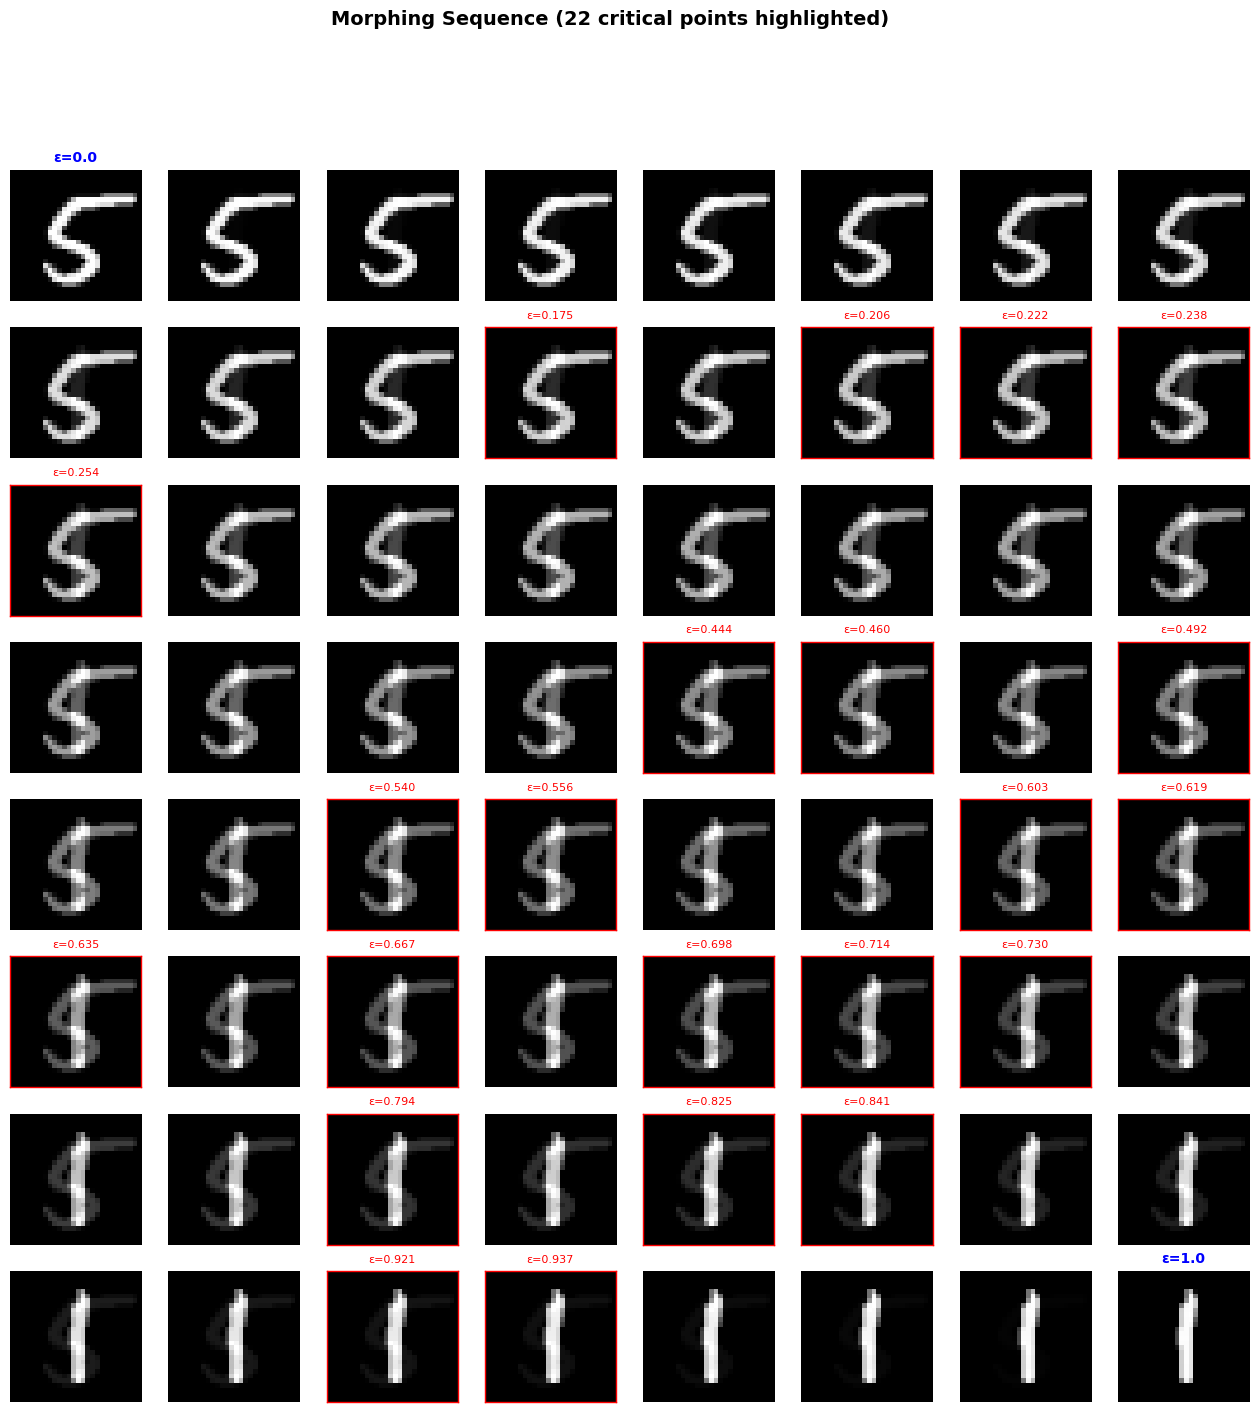

In [18]:
critical_points_eps = morph_bp_x
rows, cols = (8, 8)
total_images = rows * cols

plt.figure(figsize=(cols * 2, rows * 2))

# Create evenly spaced epsilon values for the grid
eps_values = np.linspace(0.0, 1.0, total_images)

# Find which grid positions correspond to critical points
critical_indices = []
tolerance = 0.01  # Tolerance for matching epsilon values

for idx, eps in enumerate(eps_values):
    # Check if this epsilon is close to any critical point
    if len(critical_points_eps) > 0:
        distances = np.abs(critical_points_eps - eps)
        if np.min(distances) < tolerance:
            critical_indices.append(idx)

# Display each image in the grid
for idx in range(total_images):
    eps = eps_values[idx]
    morphed_img = morph(x_ini, x_end, eps)
    
    ax = plt.subplot(rows, cols, idx + 1)
    ax.imshow(morphed_img.reshape(28, 28), cmap='gray')
    
    # Highlight critical points with red border
    if idx in critical_indices:
        # Keep axis on to show the red border
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('red')
            spine.set_linewidth(1)
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        # Turn off axis for non-critical points
        ax.axis('off')
    
    # Add epsilon label for corner images
    if idx == 0:
        ax.set_title('ε=0.0', fontsize=10, color='blue', fontweight='bold')
    elif idx == total_images - 1:
        ax.set_title('ε=1.0', fontsize=10, color='blue', fontweight='bold')
    elif idx in critical_indices:
        ax.set_title(f'ε={eps:.3f}', fontsize=8, color='red')

plt.suptitle(f'Morphing Sequence ({len(critical_indices)} critical points highlighted)', 
                fontsize=14, fontweight='bold')

plt.show()

## Result Interpretation

**Extraction success rate:**
- **Neurons Extracted:** 11 out of 16 neurons (68.8%)
- **Critical Points Analysed:** 22 across 10 image pairs

**Key findings:**

1. **Feasibility of Black-Box extraction:**
The attack successfully extracted weight signatures for 11 of first hidden layer neurons using only model queries. This demonstrates that simple neural networks are vulnerable to model extraction attacks.

2. **Critical point distribution:**
- Each image pair morphing produced critical points
- Not all critical points correspond to unique neurons (some neurons toggle multiple times)

3. **Morphing visualisation insights:**
- **Smooth transitions** between digit images with distinct critical points where neuron activations change
- **Red frames** indicate critical points where the network's neurons toggle 


### Security implications

**Vulnerability assessment:**

1. **Model intellectual property theft:**
- Attackers can reconstruct significant portions of a proprietary model by extracting the weights and biases
- Weight extraction enables model cloning without training data or computational resources

2. **Privacy concerns:**
- Extracted weights may encode information about training data
- Enables further attacks like membership inference or data extraction

**Limitations of this attack:**

1. **Partial extraction:** Only first hidden layer weights extracted
2. **Architecture knowledge:** Attack assumes knowledge of layer sizes and activation functions
3. **Numerical stability:** Requires careful tuning of tolerance parameters (ε, tol)
4. **Randomness dependence:** Success varies with random image pair selection



## References 

[1] 	Z. S. W. C. Yibo Sun, “The evolution of object detection methods,” Engineering Applications of Artificial Intelligence, vol. 133, 2024. 

[2] 	D. B. D. K. S. M. A. Fnu Neha, “From classical techniques to convolution-based models: A review of object detection algorithms,” in IEEE 6th International Conference on Image Processing, Applications and Systems (IPAS), Lyon, 2025. 

[3] 	A. B. Amjoud and M. Amrouch, “Object Detection Using Deep Learning, CNNs and Vision Transformers: A Review,” IEEE Access, vol. 11, 2023. 

[4] 	I. S. G. E. H. Alex Krizhevsky, “ImageNet Classification with Deep Convolutional Neural Networks,” in Advances in Neural Information Processing Systems 25 (NIPS 2012), 2012. 

[5] 	A. Z. Karen Simonyan, “Very Deep Convolutional Networks for Large-Scale Image Recognition,” arXiv preprint, 2014. 

[6] 	M. S. A. H. M. Z. A. Z. L.-C. Chen, “MobileNetV2: Inverted Residuals and Linear Bottlenecks,” in IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2018. 

[7] 	I. R. M. D. M. K. D. F. Kezhen Chen, “Human- ike Sketch Object Recognition v ia Analogical Learning,” in AAAI Conference on Artificial Intelligence. 

[8] 	C. M. Bishop, Pattern Recognition and Machine Learning, Springer New York, NY. 

[9] 	T. A. Nayeem, S. M. Motaharuzzaman, A. T. Hoque and M. H. Rahman, “Computer Vision Based Object Detection and Recognition System for Image Searching,” in 2022 12th International Conference on Electrical and Computer Engineering (ICECE), Dhaka, 2023. 

[10]    Y. N. N. P. T. S. D. N. J. P. R. .. L. Ridam Lokhande, “Object Detection,” International Journal of Advanced Research in Science, Communication and Technology (IJARSCT), vol. 3, 2023. 

[11]    Carlini, N., Jagielski, M., Mironov, I. (2020). Cryptanalytic Extraction of Neural Network Models. In: Micciancio, D., Ristenpart, T. (eds) Advances in Cryptology – CRYPTO 2020. CRYPTO 2020. Lecture Notes in Computer Science(), vol 12172. Springer, Cham. https://doi.org/10.1007/978-3-030-56877-1_7

[12]    Canales-Martínez, I.A., Chávez-Saab, J., Hambitzer, A., Rodríguez-Henríquez, F., Satpute, N., Shamir, A. (2024). Polynomial Time Cryptanalytic Extraction of Neural Network Models. In: Joye, M., Leander, G. (eds) Advances in Cryptology – EUROCRYPT 2024. EUROCRYPT 2024. Lecture Notes in Computer Science, vol 14653. Springer, Cham. https://doi.org/10.1007/978-3-031-58734-4_1

[13]    Carlini, N., Chávez-Saab, J., Hambitzer, A., Rodríguez-Henríquez, F., Shamir, A. (2025). Polynomial Time Cryptanalytic Extraction of Deep Neural Networks in the Hard-Label Setting. In: Fehr, S., Fouque, PA. (eds) Advances in Cryptology – EUROCRYPT 2025. EUROCRYPT 2025. Lecture Notes in Computer Science, vol 15601. Springer, Cham. https://doi.org/10.1007/978-3-031-91107-1_13

[14]    Y. LeCun, "MNIST dataset," Hugging Face. [Online]. Available: https://huggingface.co/datasets/ylecun/mnist.

NOTE: Part of TII (Technology Innovation Institute) code used in BlackBox and WhiteBox classes. Available at: https://github.com/Crypto-TII/deti?tab=readme-ov-file